Simulation starts.
BM increments sampled.
Volterra kernel matrix computed.
Volterra paths generated.
Volatility paths generated.
Price at maturity generated.
Malliavin weights generated.


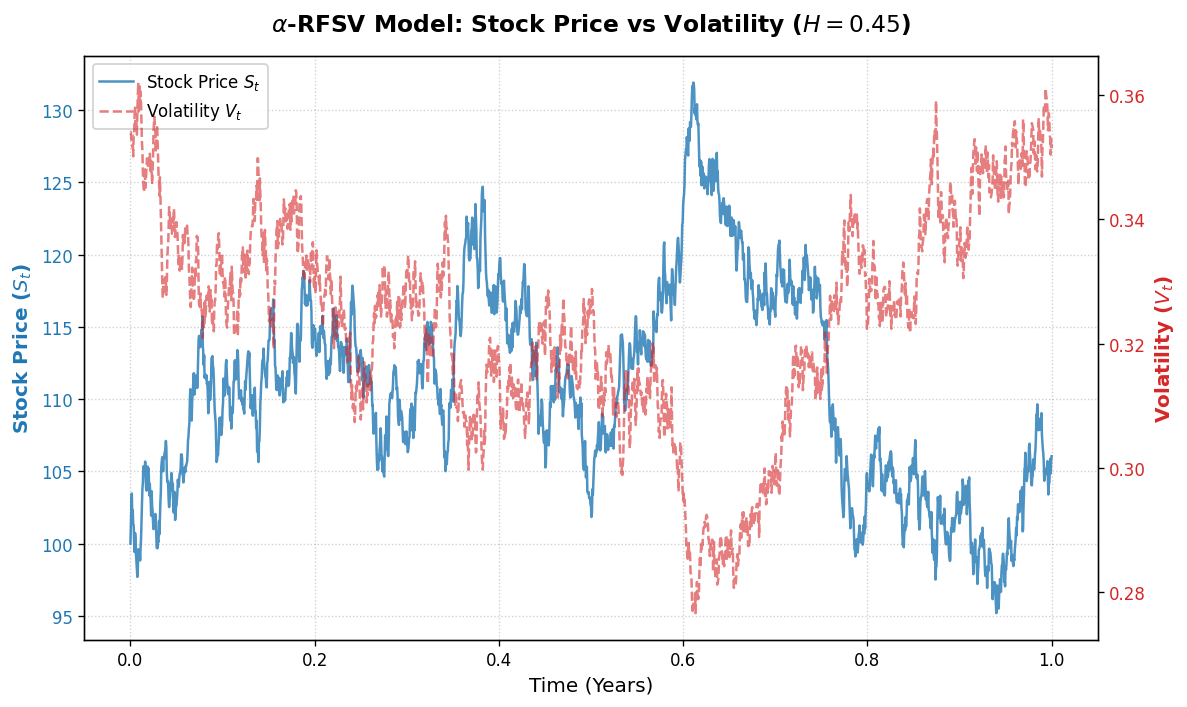

In [6]:
import random

from matplotlib import pyplot as plt
import numpy as np
import torch


# Model params
H = 0.45           # Hurst parameter
alpha = 1.0        # rough Bergomi
V0 = 0.354         # Initial volatility
xi = 0.212         # Vol of vol
rho = -0.756       # Correlation
eps = 1e-6         # Smoothing parameter for the kernel
S0 = 100.0
r = 0.05
T = 1.0

# Simulation params
Nsteps = 2_000
Npaths = 200_000

h = 1e-5           # Finite difference step

# CUDA device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Payoffs


def payoff_call(S_T, K):
    return torch.relu(S_T - K)


def payoff_put(S_T, K):
    return torch.relu(K - S_T)


def payoff_digital_call(S_T, K):
    return (S_T > K).float()

def payoff_digital_put(S_T, K):
    return (S_T < K).float()

def payoff_gap_call(S_T, K1, K2):
    return (S_T > K1).float() * torch.relu(S_T - K2)

def payoff_gap_put(S_T, K1, K2):
    return (S_T < K1).float() * torch.relu(K2 - S_T)


# Simulate
print("Simulation starts.")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

dt = T / Nsteps
t = torch.linspace(dt, T, Nsteps, device=device)  # (Nsteps,)

# BM increments
dW1 = torch.randn(Npaths, Nsteps, device=device) * \
    np.sqrt(dt)  # (Npaths, Nsteps)
dW2 = torch.randn(Npaths, Nsteps, device=device) * \
    np.sqrt(dt)  # (Npaths, Nsteps)
dZ = rho * dW1 + np.sqrt(1 - rho**2) * dW2  # (Npaths, Nsteps)
del dW2
print("BM increments sampled.")

# Volterra kernel matrix
# K_H(t, s) = sqrt(2H) * (t - s + eps)^(H - 0.5)
t_col = t.view(-1, 1)
s_row = t.view(1, -1)
diff = t_col - s_row
mask = diff > 0
K_matrix = torch.zeros((Nsteps, Nsteps), device=device)
K_matrix[mask] = np.sqrt(2 * H) * (diff[mask] + eps)**(H - 0.5)
del t_col, s_row, diff, mask
print("Volterra kernel matrix computed.")

# Volterra paths
Y = dZ @ K_matrix.T  # (Npaths, Nsteps)
del dZ, K_matrix
print("Volterra paths generated.")


# Volatility paths
# r(t) = (t+eps)^(2H) - eps^(2H)
# V_t = V0 * exp(xi * Y_t - 0.5 * alpha * xi^2 * r(t))
r_t = (t + eps)**(2 * H) - eps**(2 * H)  # (Nsteps,)
V = V0 * torch.exp(xi * Y - 0.5 * alpha * (xi**2) * r_t)
del Y, r_t
print("Volatility paths generated.")

# Price at maturity
int_V2_dt = torch.sum((V**2) * dt, dim=1)
int_V_dW = torch.sum(V * dW1, dim=1)
log_return = r * T - 0.5 * int_V2_dt + int_V_dW
S_T = S0 * torch.exp(log_return)
S_T_upper = (S0 + h) * torch.exp(log_return)
S_T_lower = (S0 - h) * torch.exp(log_return)
del int_V2_dt, int_V_dW, log_return
print("Price at maturity generated.")

# kappa_t
kappa_t = np.sqrt(2 * H) / (H + 0.5) * ((t + eps) **
                                        (H + 0.5) - eps**(H + 0.5))  # (Nsteps,)

# G_T
int_V_dt = torch.sum(V * dt, dim=1)
int_V_kappa_dW = torch.sum(V * kappa_t * dW1, dim=1)
int_V2_kappa_dt = torch.sum((V**2) * kappa_t * dt, dim=1)
G_T = int_V_dt + rho * xi * (int_V_kappa_dW - int_V2_kappa_dt)
del int_V_dt, int_V_kappa_dW, int_V2_kappa_dt

# D_sG_T
int_V_kappa_dt = torch.sum(V * kappa_t * dt, dim=1)
int_V_kappa2_dW = torch.sum(V * (kappa_t**2) * dW1, dim=1)
int_V2_kappa2_dt = torch.sum((V**2) * (kappa_t**2) * dt, dim=1)
int_Ds_GT_ds = 2 * rho * xi * int_V_kappa_dt + \
    (rho * xi)**2 * (int_V_kappa2_dW - 2 * int_V2_kappa2_dt)
del int_V_kappa_dt, int_V_kappa2_dW, int_V2_kappa2_dt

# D_tD_sG_T
int_kappa2_V_dt = torch.sum((kappa_t**2) * V * dt, dim=1)
int_kappa3_V_dW = torch.sum((kappa_t**3) * V * dW1, dim=1)
int_kappa3_V2_dt = torch.sum((kappa_t**3) * (V**2) * dt, dim=1)
int_Dt_Ds_GT = 3 * (rho * xi)**2 * int_kappa2_V_dt - \
    (rho * xi)**3 * (int_kappa3_V_dW - 4 * int_kappa3_V2_dt)
del kappa_t, int_kappa2_V_dt, int_kappa3_V_dW, int_kappa3_V2_dt

# Malliavin weights
W_T = torch.sum(dW1, dim=1)
weight_delta = (W_T / G_T + int_Ds_GT_ds / (G_T**2))
term1 = -weight_delta
term2 = (weight_delta**2)
term3 = - (T / G_T - W_T * int_Ds_GT_ds / (G_T**2) + int_Dt_Ds_GT /
           G_T - 2 * (int_Ds_GT_ds**2) / (G_T**3))
weight_gamma = term1 + term2 + term3
del G_T, int_Ds_GT_ds, int_Dt_Ds_GT, term1, term2, term3
print("Malliavin weights generated.")

# Plot first 3 paths
int_V2_dt_path = torch.cumsum((V[0, :]**2) * dt, 0)
int_V_dW_path = torch.cumsum(V[0, :] * dW1[0, :], 0)
S_path = S0 * torch.exp(r * t - 0.5 * int_V2_dt_path + int_V_dW_path)

V_np = np.insert(V[0, :].cpu().numpy(), 0, V0)
S_np = np.insert(S_path.cpu().numpy(), 0, S0)
t_np = np.insert(t.cpu().numpy(), 0, 0.0)
del int_V2_dt_path, int_V_dW_path, S_path, dW1

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=120)

color_S = "#1f77b4"
ax1.set_xlabel("Time (Years)", fontsize=12)
ax1.set_ylabel("Stock Price ($S_t$)", color=color_S, fontsize=12, fontweight="bold")
label = "Stock Price $S_t$"
ax1.plot(t_np, S_np, color=color_S, alpha=0.8, linewidth=1.5, label=label)
ax1.tick_params(axis="y", labelcolor=color_S)

ax2 = ax1.twinx()
color_V = "#d62728"
ax2.set_ylabel(r"Volatility ($V_t$)", color=color_V, fontsize=12, fontweight="bold")
label = "Volatility $V_t$"
ax2.plot(t_np, V_np, color=color_V, alpha=0.6, linewidth=1.5, linestyle="--", label=label)
ax2.tick_params(axis="y", labelcolor=color_V)

plt.title(rf"$\alpha$-RFSV Model: Stock Price vs Volatility ($H={H}$)", fontsize=14, fontweight="bold", pad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", framealpha=0.9)

ax1.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## European Vanilla Call

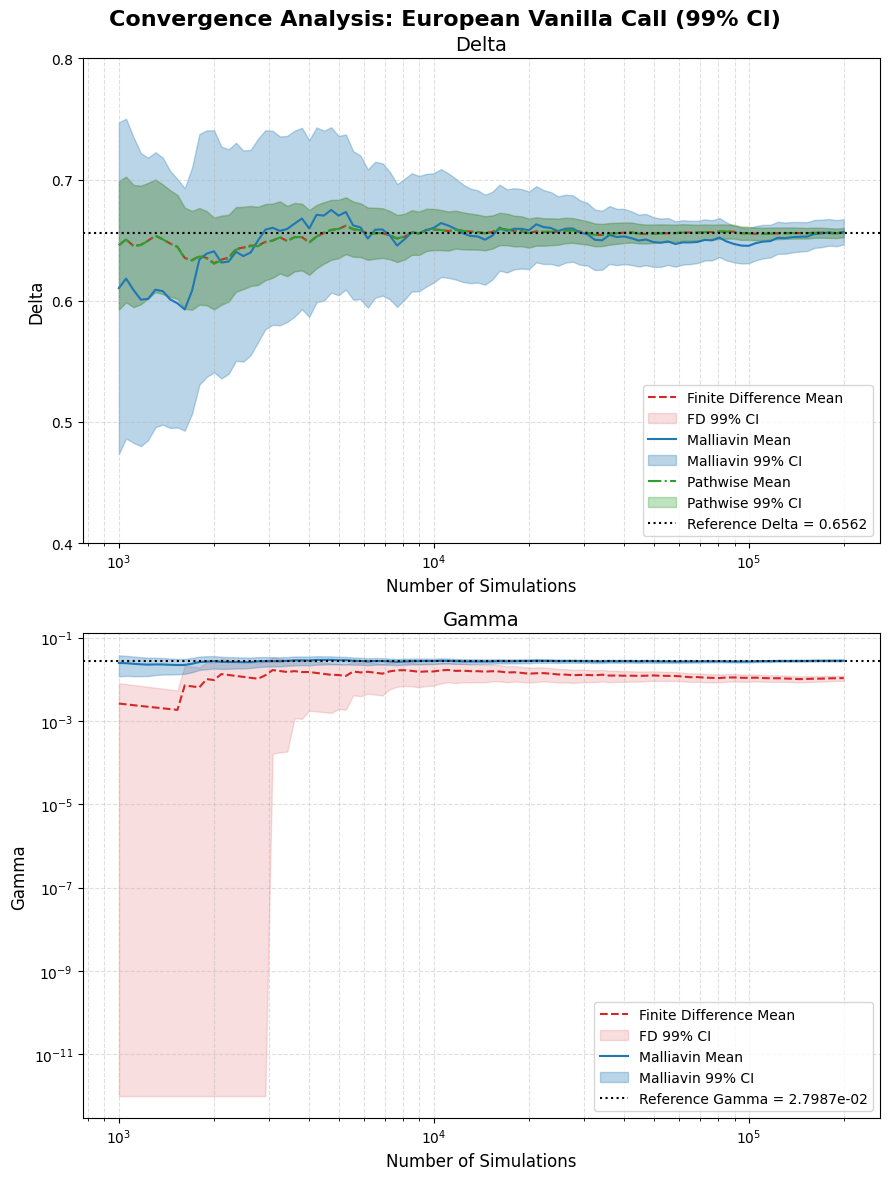

In [7]:
from scipy import stats
from matplotlib.ticker import FormatStrFormatter


discount_factor = np.exp(-r * T)

# Use a larger relative bump for finite differences to reduce gamma noise.
h_fd = max(1e-3 * S0, 0.1)
scale_up = (S0 + h_fd) / S0
scale_dn = (S0 - h_fd) / S0

# S_T is linear in S0 under shared Brownian paths, so this is exact for bumped initials.
S_T_upper_fd = S_T * scale_up
S_T_lower_fd = S_T * scale_dn

title_suffix = "European Vanilla Call"
K = 100.0
payoff = payoff_call(S_T, K)
payoff_upper = payoff_call(S_T_upper_fd, K)
payoff_lower = payoff_call(S_T_lower_fd, K)

delta_mal = (discount_factor * payoff * weight_delta / S0).cpu().numpy()
delta_fd = (discount_factor * (payoff_upper - payoff_lower) / (2 * h_fd)).cpu().numpy()
delta_path = (discount_factor * payoff_digital_call(S_T, K) * (S_T / S0)).cpu().numpy()

# Reference lines.
delta_ref = float(np.mean(delta_path))

gamma_mal = (discount_factor * payoff * weight_gamma / S0**2).cpu().numpy()
gamma_fd = (discount_factor * (payoff_upper - 2 * payoff + payoff_lower) / (h_fd**2)).cpu().numpy()
gamma_ref = float(np.mean(gamma_mal))

ci_level = 0.99
z_score = stats.norm.ppf(1 - (1 - ci_level) / 2)
checkpoints = np.unique(np.logspace(np.log10(1000), np.log10(Npaths), num=100).astype(int))

fig, axes = plt.subplots(2, 1, figsize=(9, 12))
fig.suptitle(f"Convergence Analysis: {title_suffix} (99% CI)", fontsize=16, fontweight="bold")

greeks = ["Delta", "Gamma"]
colors = {"Malliavin": "#1f77b4", "FD": "#d62728", "Pathwise": "#2ca02c"}
for i, greek in enumerate(greeks):
    ax = axes[i]
    
    if greek == "Delta":
        mal_data = delta_mal
        fd_data = delta_fd
        path_data = delta_path
    elif greek == "Gamma":
        mal_data = gamma_mal
        fd_data = gamma_fd
    else:
        raise Exception("Unknown Greek")
    
    mal_means, mal_errs = [], []
    fd_means, fd_errs = [], []
    path_means, path_errs = [], []
    
    for n in checkpoints:
        slice_mal = mal_data[:n]
        slice_fd = fd_data[:n]
        
        # Malliavin
        mal_means.append(np.mean(slice_mal))
        mal_errs.append(z_score * np.std(slice_mal, ddof=1) / np.sqrt(n))
        
        # Finite Difference
        fd_means.append(np.mean(slice_fd))
        fd_errs.append(z_score * np.std(slice_fd, ddof=1) / np.sqrt(n))
        
        # Pathwise Derivative
        if greek == "Delta":
            path_means.append(np.mean(path_data[:n]))
            path_errs.append(z_score * np.std(path_data[:n], ddof=1) / np.sqrt(n))
        
    mal_means, mal_errs = np.array(mal_means), np.array(mal_errs)
    fd_means, fd_errs = np.array(fd_means), np.array(fd_errs)
    if greek == "Delta":
        path_means, path_errs = np.array(path_means), np.array(path_errs)
    
    fd_lower = fd_means - fd_errs
    fd_upper = fd_means + fd_errs
    mal_lower = mal_means - mal_errs
    mal_upper = mal_means + mal_errs

    # Avoid invalid lower bounds on log-y gamma plot.
    if greek == "Gamma":
        tiny = 1e-12
        fd_lower = np.maximum(fd_lower, tiny)
        mal_lower = np.maximum(mal_lower, tiny)

    ax.plot(checkpoints, fd_means, label="Finite Difference Mean", color=colors["FD"], linewidth=1.5, linestyle="--")
    ax.fill_between(checkpoints, fd_lower, fd_upper, color=colors["FD"], alpha=0.15, label="FD 99% CI")

    ax.plot(checkpoints, mal_means, label="Malliavin Mean", color=colors["Malliavin"], linewidth=1.5)
    ax.fill_between(checkpoints, mal_lower, mal_upper, color=colors["Malliavin"], alpha=0.3, label="Malliavin 99% CI")
    
    if greek == "Delta":
        path_lower = path_means - path_errs
        path_upper = path_means + path_errs
        ax.plot(checkpoints, path_means, label="Pathwise Mean", color=colors["Pathwise"], linewidth=1.5, linestyle="-.")
        ax.fill_between(checkpoints, path_lower, path_upper, color=colors["Pathwise"], alpha=0.3, label="Pathwise 99% CI")
        ax.axhline(delta_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Delta = {delta_ref:.4f}")
    elif greek == "Gamma":
        ax.axhline(gamma_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Gamma = {gamma_ref:.4e}")
    
    ax.set_title(greek, fontsize=14)
    ax.set_xlabel("Number of Simulations", fontsize=12)
    ax.set_ylabel(greek, fontsize=12)
    ax.set_xscale("log")

    if greek == "Delta":
        ax.set_yscale("linear")
        ax.set_ylim(0.4, 0.8)
        ax.set_yticks(np.arange(0.4, 0.81, 0.1))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    else:
        ax.set_yscale("log")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

## European Vanilla Put

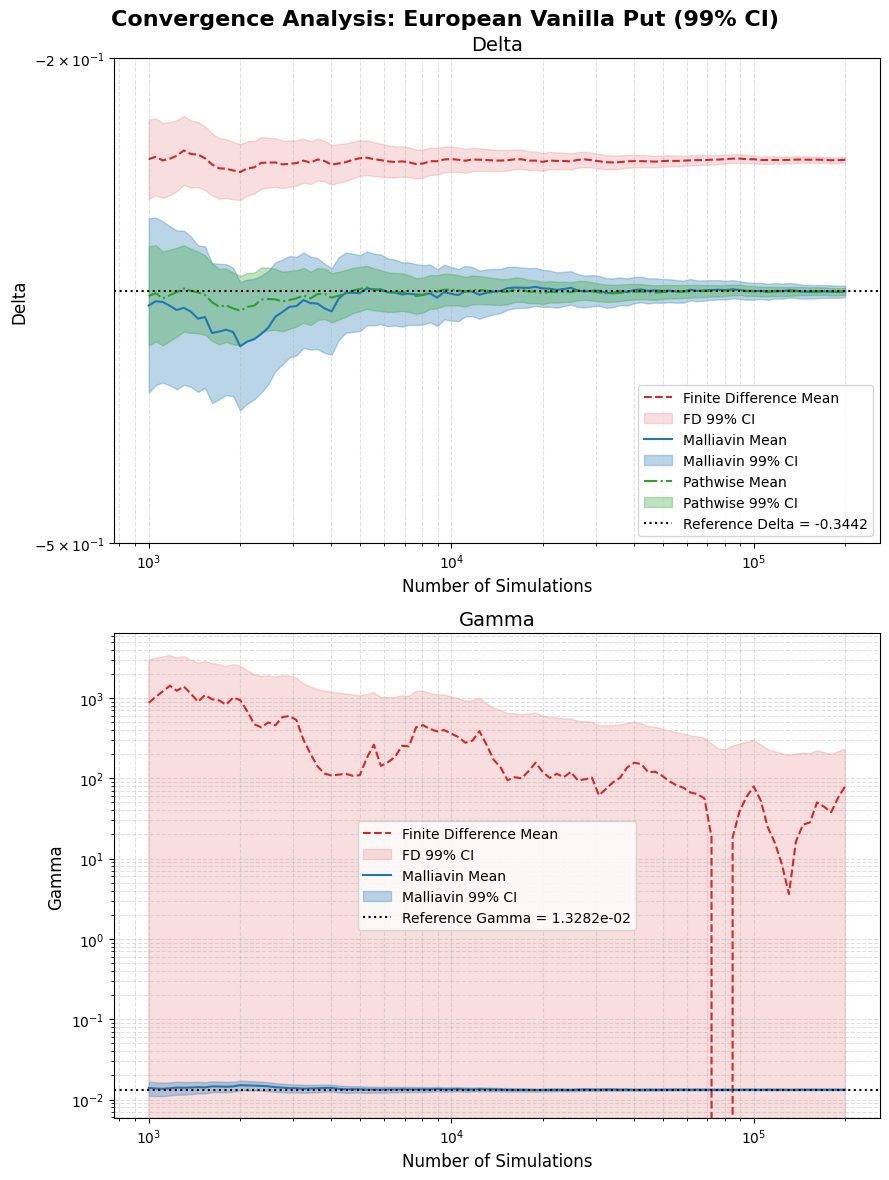

In [8]:
from scipy import stats


discount_factor = np.exp(-r * T)

title_suffix = "European Vanilla Put"
K = 100.0
payoff = payoff_put(S_T, K)
payoff_upper = payoff_put(S_T_upper, K)
payoff_lower = payoff_put(S_T_lower, K)

delta_mal = (discount_factor * payoff * weight_delta / S0).cpu().numpy()
delta_fd = (discount_factor * (payoff_upper - payoff_lower) / (2*h)).cpu().numpy()
delta_path = (discount_factor * -payoff_digital_put(S_T, K) * (S_T / S0)).cpu().numpy()
delta_ref = float(np.mean(delta_path))

gamma_mal = (discount_factor * payoff * weight_gamma / S0**2).cpu().numpy()
gamma_fd = (discount_factor * (payoff_upper - 2 * payoff + payoff_lower) / (h**2)).cpu().numpy()
gamma_ref = float(np.mean(gamma_mal))

ci_level = 0.99
z_score = stats.norm.ppf(1 - (1 - ci_level) / 2)
checkpoints = np.unique(np.logspace(np.log10(1000), np.log10(Npaths), num=100).astype(int))

fig, axes = plt.subplots(2, 1, figsize=(9, 12))
fig.suptitle(f"Convergence Analysis: {title_suffix} (99% CI)", fontsize=16, fontweight="bold")

greeks = ["Delta", "Gamma"]
colors = {"Malliavin": "#1f77b4", "FD": "#d62728", "Pathwise": "#2ca02c"}
for i, greek in enumerate(greeks):
    ax = axes[i]
    
    if greek == "Delta":
        mal_data = delta_mal
        fd_data = delta_fd
        path_data = delta_path
    elif greek == "Gamma":
        mal_data = gamma_mal
        fd_data = gamma_fd
    else:
        raise Exception("Unknown Greek")
    
    mal_means, mal_errs = [], []
    fd_means, fd_errs = [], []
    path_means, path_errs = [], []
    
    for n in checkpoints:
        slice_mal = mal_data[:n]
        slice_fd = fd_data[:n]
        
        # Malliavin
        mal_means.append(np.mean(slice_mal))
        mal_errs.append(z_score * np.std(slice_mal, ddof=1) / np.sqrt(n))
        
        # Finite Difference
        fd_means.append(np.mean(slice_fd))
        fd_errs.append(z_score * np.std(slice_fd, ddof=1) / np.sqrt(n))
        
        # Pathwise Derivative
        if greek == "Delta":
            path_means.append(np.mean(path_data[:n]))
            path_errs.append(z_score * np.std(path_data[:n], ddof=1) / np.sqrt(n))
        
    mal_means, mal_errs = np.array(mal_means), np.array(mal_errs)
    fd_means, fd_errs = np.array(fd_means), np.array(fd_errs)
    if greek == "Delta":
        path_means, path_errs = np.array(path_means), np.array(path_errs)
    
    ax.plot(checkpoints, fd_means, label="Finite Difference Mean", color=colors["FD"], linewidth=1.5, linestyle="--")
    ax.fill_between(checkpoints, fd_means - fd_errs, fd_means + fd_errs, 
                    color=colors["FD"], alpha=0.15, label="FD 99% CI")
    
    ax.plot(checkpoints, mal_means, label="Malliavin Mean", color=colors["Malliavin"], linewidth=1.5)
    ax.fill_between(checkpoints, mal_means - mal_errs, mal_means + mal_errs, 
                    color=colors["Malliavin"], alpha=0.3, label="Malliavin 99% CI")
    
    if greek == "Delta":
        ax.plot(checkpoints, path_means, label="Pathwise Mean", color=colors["Pathwise"], linewidth=1.5, linestyle="-.")
        ax.fill_between(checkpoints, path_means - path_errs, path_means + path_errs, color=colors["Pathwise"], alpha=0.3,         label="Pathwise 99% CI")
        ax.axhline(delta_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Delta = {delta_ref:.4f}")
    elif greek == "Gamma":
        ax.axhline(gamma_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Gamma = {gamma_ref:.4e}")
    
    ax.set_title(greek, fontsize=14)
    ax.set_xlabel("Number of Simulations", fontsize=12)
    ax.set_ylabel(greek, fontsize=12)
    ax.set_xscale("log")
    if greek == "Delta":
        ax.set_yscale("symlog")
        ax.set_ylim(-0.5, -0.2)
    elif greek == "Gamma":
        ax.set_yscale("log")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

## European Digital Call

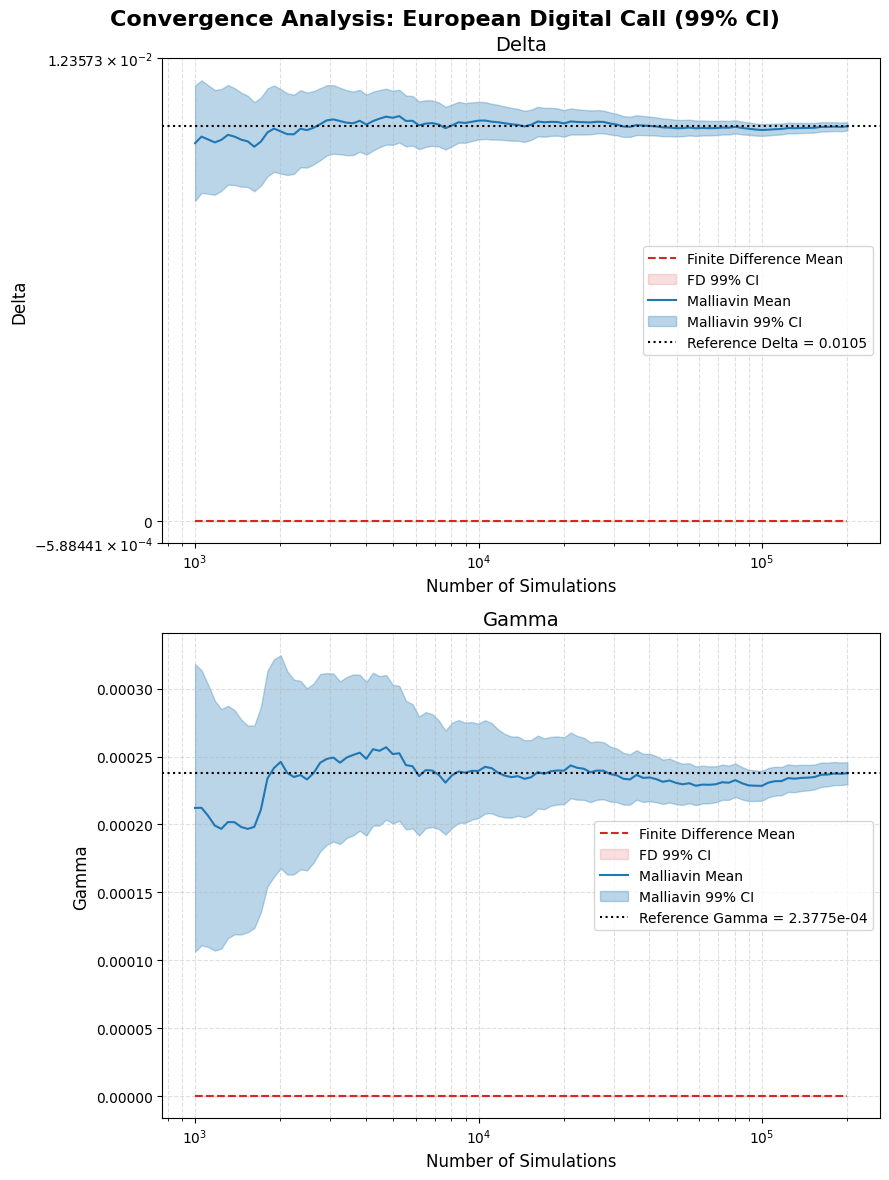

In [9]:
from scipy import stats


discount_factor = np.exp(-r * T)

title_suffix = "European Digital Call"
K = 100.0
payoff = payoff_digital_call(S_T, K)
payoff_upper = payoff_digital_call(S_T_upper, K)
payoff_lower = payoff_digital_call(S_T_lower, K)

delta_mal = (discount_factor * payoff * weight_delta / S0).cpu().numpy()
delta_fd = (discount_factor * (payoff_upper - payoff_lower) / (2*h)).cpu().numpy()
delta_ref = float(np.mean(delta_mal))

gamma_mal = (discount_factor * payoff * weight_gamma / S0**2).cpu().numpy()
gamma_fd = (discount_factor * (payoff_upper - 2 * payoff + payoff_lower) / (h**2)).cpu().numpy()
gamma_ref = float(np.mean(gamma_mal))

ci_level = 0.99
z_score = stats.norm.ppf(1 - (1 - ci_level) / 2)
checkpoints = np.unique(np.logspace(np.log10(1000), np.log10(Npaths), num=100).astype(int))

fig, axes = plt.subplots(2, 1, figsize=(9, 12))
fig.suptitle(f"Convergence Analysis: {title_suffix} (99% CI)", fontsize=16, fontweight="bold")

greeks = ["Delta", "Gamma"]
colors = {"Malliavin": "#1f77b4", "FD": "#d62728", "Pathwise": "#2ca02c"}
for i, greek in enumerate(greeks):
    ax = axes[i]
    
    if greek == "Delta":
        mal_data = delta_mal
        fd_data = delta_fd
    elif greek == "Gamma":
        mal_data = gamma_mal
        fd_data = gamma_fd
    else:
        raise Exception("Unknown Greek")
    
    mal_means, mal_errs = [], []
    fd_means, fd_errs = [], []
    
    for n in checkpoints:
        slice_mal = mal_data[:n]
        slice_fd = fd_data[:n]
        
        # Malliavin
        mal_means.append(np.mean(slice_mal))
        mal_errs.append(z_score * np.std(slice_mal, ddof=1) / np.sqrt(n))
        
        # Finite Difference
        fd_means.append(np.mean(slice_fd))
        fd_errs.append(z_score * np.std(slice_fd, ddof=1) / np.sqrt(n))
        
    mal_means, mal_errs = np.array(mal_means), np.array(mal_errs)
    fd_means, fd_errs = np.array(fd_means), np.array(fd_errs)
    if greek == "Delta":
        path_means, path_errs = np.array(path_means), np.array(path_errs)
    
    ax.plot(checkpoints, fd_means, label="Finite Difference Mean", color=colors["FD"], linewidth=1.5, linestyle="--")
    ax.fill_between(checkpoints, fd_means - fd_errs, fd_means + fd_errs, 
                    color=colors["FD"], alpha=0.15, label="FD 99% CI")
    
    ax.plot(checkpoints, mal_means, label="Malliavin Mean", color=colors["Malliavin"], linewidth=1.5)
    ax.fill_between(checkpoints, mal_means - mal_errs, mal_means + mal_errs, 
                    color=colors["Malliavin"], alpha=0.3, label="Malliavin 99% CI")

    ax.set_title(greek, fontsize=14)
    ax.set_xlabel("Number of Simulations", fontsize=12)
    ax.set_ylabel(greek, fontsize=12)
    ax.set_xscale("log")
    if greek == "Delta":
        ax.set_yscale("symlog")
        # ax.set_ylim(-0.5, -0.2)
    elif greek == "Gamma":
        # ax.set_yscale("log")
        pass
    if greek == "Delta":
        ax.axhline(delta_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Delta = {delta_ref:.4f}")
    elif greek == "Gamma":
        ax.axhline(gamma_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Gamma = {gamma_ref:.4e}")

    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

## European Digital Put

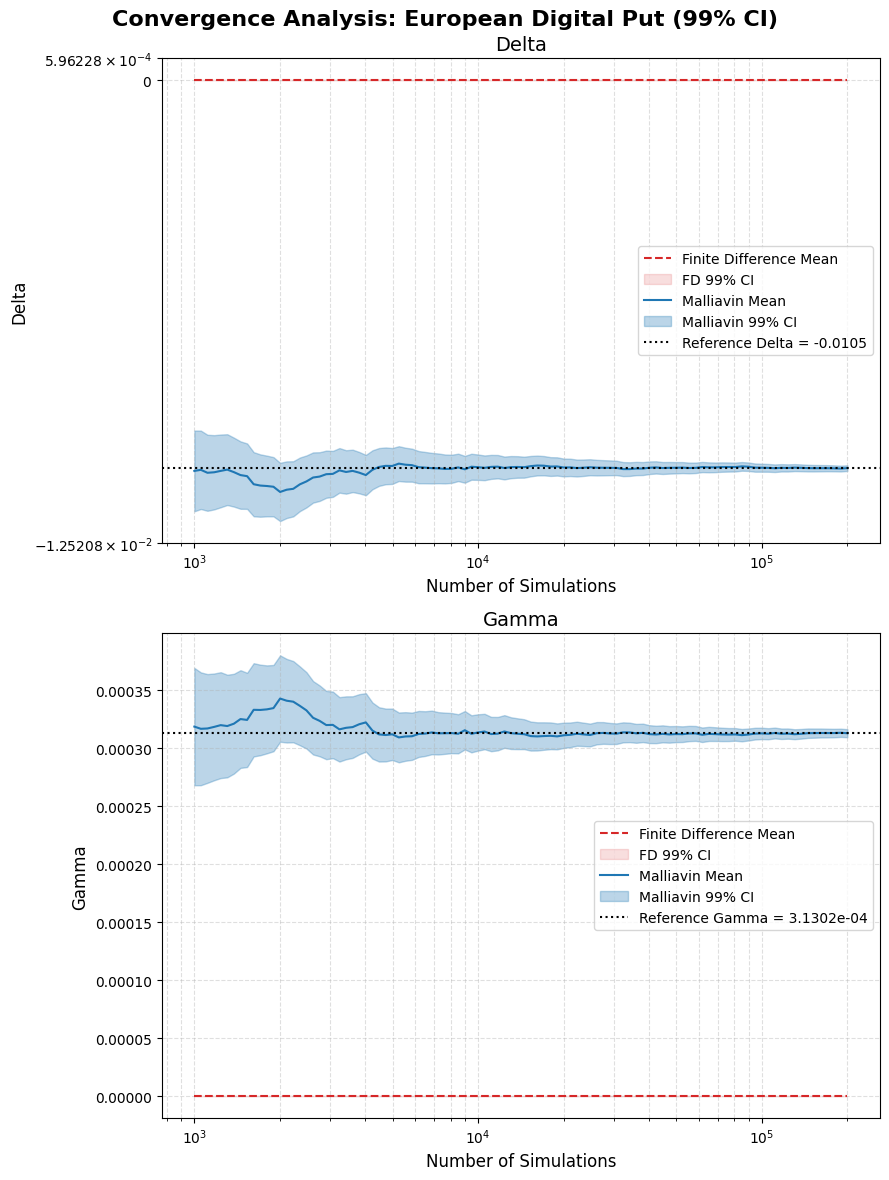

In [10]:
from scipy import stats


discount_factor = np.exp(-r * T)

title_suffix = "European Digital Put"
K = 100.0
payoff = payoff_digital_put(S_T, K)
payoff_upper = payoff_digital_put(S_T_upper, K)
payoff_lower = payoff_digital_put(S_T_lower, K)

delta_mal = (discount_factor * payoff * weight_delta / S0).cpu().numpy()
delta_fd = (discount_factor * (payoff_upper - payoff_lower) / (2*h)).cpu().numpy()
delta_ref = float(np.mean(delta_mal))

gamma_mal = (discount_factor * payoff * weight_gamma / S0**2).cpu().numpy()
gamma_fd = (discount_factor * (payoff_upper - 2 * payoff + payoff_lower) / (h**2)).cpu().numpy()
gamma_ref = float(np.mean(gamma_mal))

ci_level = 0.99
z_score = stats.norm.ppf(1 - (1 - ci_level) / 2)
checkpoints = np.unique(np.logspace(np.log10(1000), np.log10(Npaths), num=100).astype(int))

fig, axes = plt.subplots(2, 1, figsize=(9, 12))
fig.suptitle(f"Convergence Analysis: {title_suffix} (99% CI)", fontsize=16, fontweight="bold")

greeks = ["Delta", "Gamma"]
colors = {"Malliavin": "#1f77b4", "FD": "#d62728", "Pathwise": "#2ca02c"}
for i, greek in enumerate(greeks):
    ax = axes[i]
    
    if greek == "Delta":
        mal_data = delta_mal
        fd_data = delta_fd
    elif greek == "Gamma":
        mal_data = gamma_mal
        fd_data = gamma_fd
    else:
        raise Exception("Unknown Greek")
    
    mal_means, mal_errs = [], []
    fd_means, fd_errs = [], []
    
    for n in checkpoints:
        slice_mal = mal_data[:n]
        slice_fd = fd_data[:n]
        
        # Malliavin
        mal_means.append(np.mean(slice_mal))
        mal_errs.append(z_score * np.std(slice_mal, ddof=1) / np.sqrt(n))
        
        # Finite Difference
        fd_means.append(np.mean(slice_fd))
        fd_errs.append(z_score * np.std(slice_fd, ddof=1) / np.sqrt(n))
        
    mal_means, mal_errs = np.array(mal_means), np.array(mal_errs)
    fd_means, fd_errs = np.array(fd_means), np.array(fd_errs)
    
    ax.plot(checkpoints, fd_means, label="Finite Difference Mean", color=colors["FD"], linewidth=1.5, linestyle="--")
    ax.fill_between(checkpoints, fd_means - fd_errs, fd_means + fd_errs, 
                    color=colors["FD"], alpha=0.15, label="FD 99% CI")
    
    ax.plot(checkpoints, mal_means, label="Malliavin Mean", color=colors["Malliavin"], linewidth=1.5)
    ax.fill_between(checkpoints, mal_means - mal_errs, mal_means + mal_errs, 
                    color=colors["Malliavin"], alpha=0.3, label="Malliavin 99% CI")

    ax.set_title(greek, fontsize=14)
    ax.set_xlabel("Number of Simulations", fontsize=12)
    ax.set_ylabel(greek, fontsize=12)
    ax.set_xscale("log")
    if greek == "Delta":
        ax.set_yscale("symlog")
        # ax.set_ylim(-0.5, -0.2)
    elif greek == "Gamma":
        # ax.set_yscale("log")
        pass
    if greek == "Delta":
        ax.axhline(delta_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Delta = {delta_ref:.4f}")
    elif greek == "Gamma":
        ax.axhline(gamma_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Gamma = {gamma_ref:.4e}")

    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

## European Gap Call

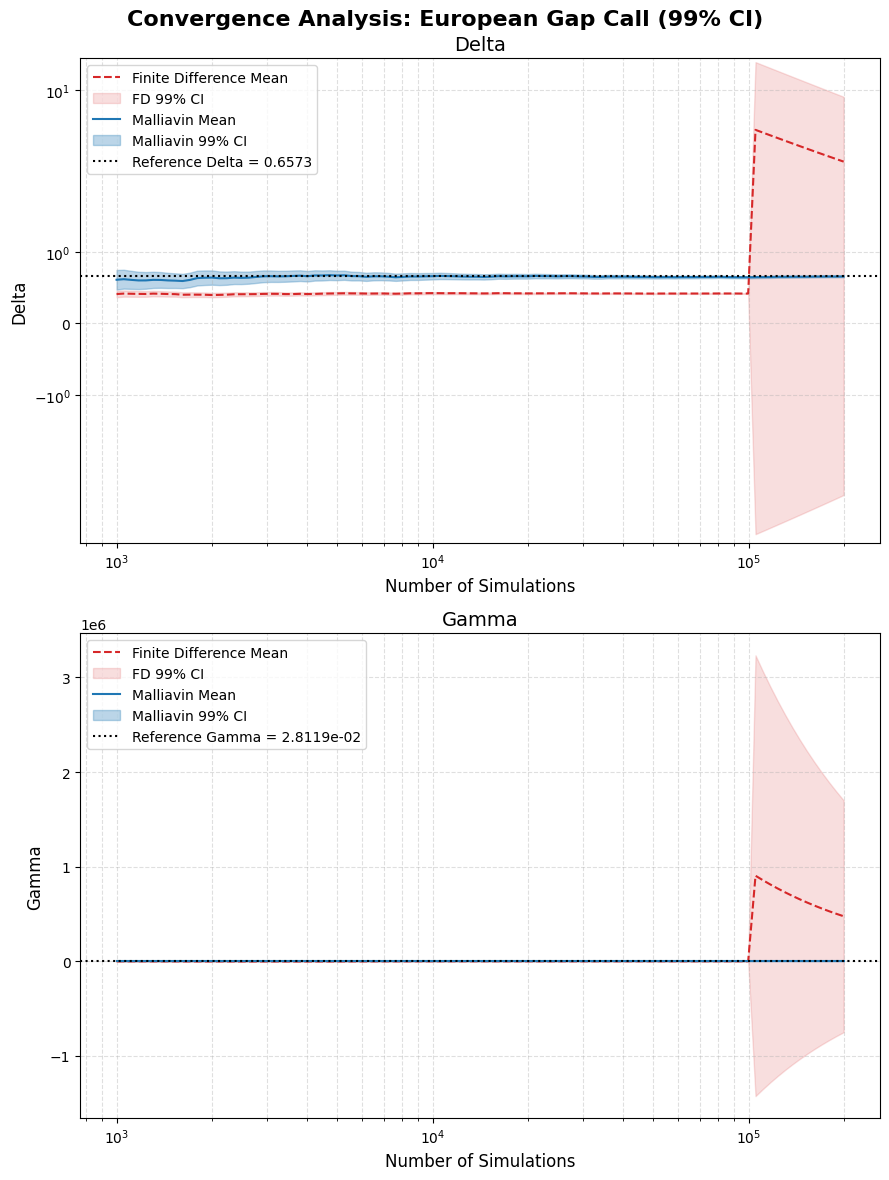

In [11]:
from scipy import stats


discount_factor = np.exp(-r * T)

title_suffix = "European Gap Call"
K1 = 110.0
K2 = 100.0
payoff = payoff_gap_call(S_T, K1, K2)
payoff_upper = payoff_gap_call(S_T_upper, K1, K2)
payoff_lower = payoff_gap_call(S_T_lower, K1, K2)

delta_mal = (discount_factor * payoff * weight_delta / S0).cpu().numpy()
delta_fd = (discount_factor * (payoff_upper - payoff_lower) / (2*h)).cpu().numpy()
delta_ref = float(np.mean(delta_mal))

gamma_mal = (discount_factor * payoff * weight_gamma / S0**2).cpu().numpy()
gamma_fd = (discount_factor * (payoff_upper - 2 * payoff + payoff_lower) / (h**2)).cpu().numpy()
gamma_ref = float(np.mean(gamma_mal))

ci_level = 0.99
z_score = stats.norm.ppf(1 - (1 - ci_level) / 2)
checkpoints = np.unique(np.logspace(np.log10(1000), np.log10(Npaths), num=100).astype(int))

fig, axes = plt.subplots(2, 1, figsize=(9, 12))
fig.suptitle(f"Convergence Analysis: {title_suffix} (99% CI)", fontsize=16, fontweight="bold")

greeks = ["Delta", "Gamma"]
colors = {"Malliavin": "#1f77b4", "FD": "#d62728", "Pathwise": "#2ca02c"}
for i, greek in enumerate(greeks):
    ax = axes[i]
    
    if greek == "Delta":
        mal_data = delta_mal
        fd_data = delta_fd
    elif greek == "Gamma":
        mal_data = gamma_mal
        fd_data = gamma_fd
    else:
        raise Exception("Unknown Greek")
    
    mal_means, mal_errs = [], []
    fd_means, fd_errs = [], []
    
    for n in checkpoints:
        slice_mal = mal_data[:n]
        slice_fd = fd_data[:n]
        
        # Malliavin
        mal_means.append(np.mean(slice_mal))
        mal_errs.append(z_score * np.std(slice_mal, ddof=1) / np.sqrt(n))
        
        # Finite Difference
        fd_means.append(np.mean(slice_fd))
        fd_errs.append(z_score * np.std(slice_fd, ddof=1) / np.sqrt(n))
        
    mal_means, mal_errs = np.array(mal_means), np.array(mal_errs)
    fd_means, fd_errs = np.array(fd_means), np.array(fd_errs)
    
    ax.plot(checkpoints, fd_means, label="Finite Difference Mean", color=colors["FD"], linewidth=1.5, linestyle="--")
    ax.fill_between(checkpoints, fd_means - fd_errs, fd_means + fd_errs, 
                    color=colors["FD"], alpha=0.15, label="FD 99% CI")
    
    ax.plot(checkpoints, mal_means, label="Malliavin Mean", color=colors["Malliavin"], linewidth=1.5)
    ax.fill_between(checkpoints, mal_means - mal_errs, mal_means + mal_errs, 
                    color=colors["Malliavin"], alpha=0.3, label="Malliavin 99% CI")

    ax.set_title(greek, fontsize=14)
    ax.set_xlabel("Number of Simulations", fontsize=12)
    ax.set_ylabel(greek, fontsize=12)
    ax.set_xscale("log")
    if greek == "Delta":
        ax.set_yscale("symlog")
        # ax.set_ylim(-0.5, -0.2)
    elif greek == "Gamma":
        # ax.set_yscale("log")
        pass
    if greek == "Delta":
        ax.axhline(delta_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Delta = {delta_ref:.4f}")
    elif greek == "Gamma":
        ax.axhline(gamma_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Gamma = {gamma_ref:.4e}")

    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

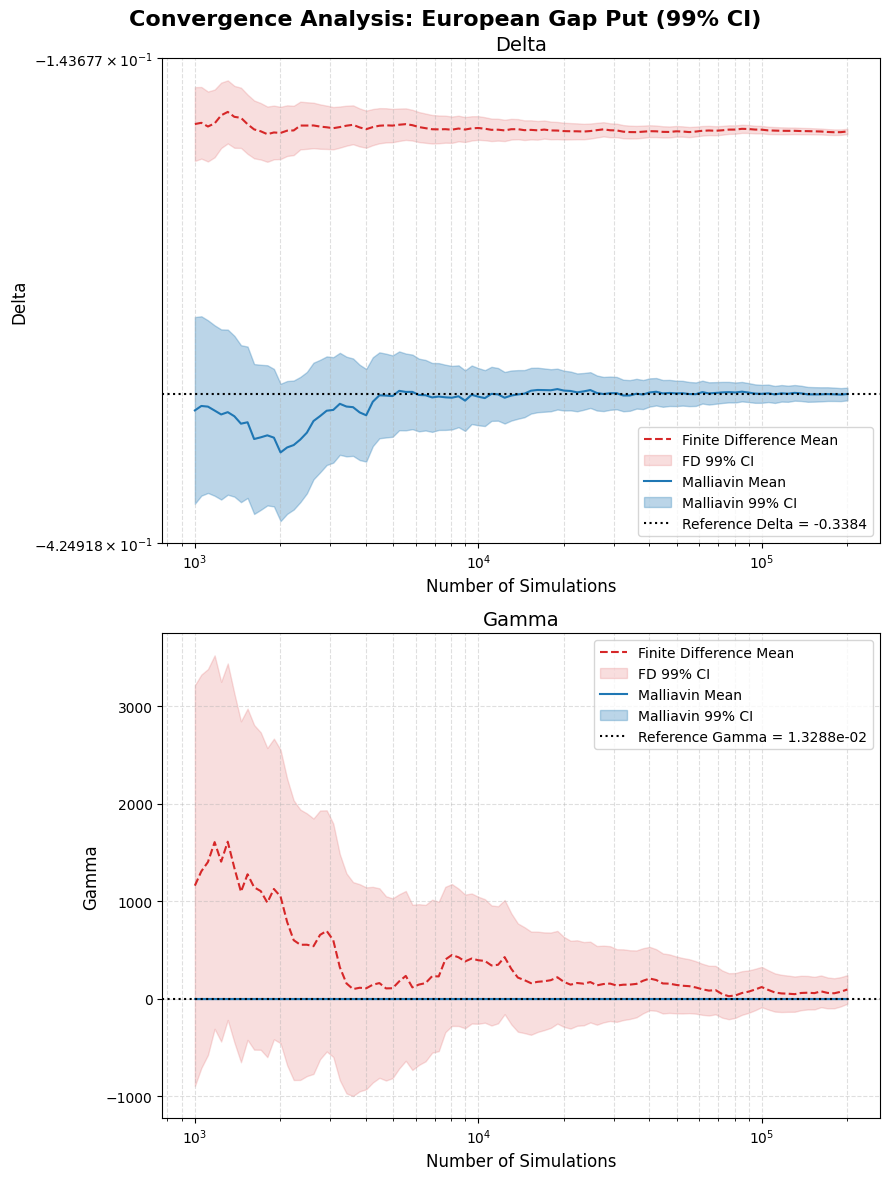

In [5]:
from scipy import stats


discount_factor = np.exp(-r * T)

title_suffix = "European Gap Put"
K1 = 90.0
K2 = 100.0
payoff = payoff_gap_put(S_T, K1, K2)
payoff_upper = payoff_gap_put(S_T_upper, K1, K2)
payoff_lower = payoff_gap_put(S_T_lower, K1, K2)

delta_mal = (discount_factor * payoff * weight_delta / S0).cpu().numpy()
delta_fd = (discount_factor * (payoff_upper - payoff_lower) / (2*h)).cpu().numpy()
delta_ref = float(np.mean(delta_mal))

gamma_mal = (discount_factor * payoff * weight_gamma / S0**2).cpu().numpy()
gamma_fd = (discount_factor * (payoff_upper - 2 * payoff + payoff_lower) / (h**2)).cpu().numpy()
gamma_ref = float(np.mean(gamma_mal))

ci_level = 0.99
z_score = stats.norm.ppf(1 - (1 - ci_level) / 2)
checkpoints = np.unique(np.logspace(np.log10(1000), np.log10(Npaths), num=100).astype(int))

fig, axes = plt.subplots(2, 1, figsize=(9, 12))
fig.suptitle(f"Convergence Analysis: {title_suffix} (99% CI)", fontsize=16, fontweight="bold")

greeks = ["Delta", "Gamma"]
colors = {"Malliavin": "#1f77b4", "FD": "#d62728", "Pathwise": "#2ca02c"}
for i, greek in enumerate(greeks):
    ax = axes[i]
    
    if greek == "Delta":
        mal_data = delta_mal
        fd_data = delta_fd
    elif greek == "Gamma":
        mal_data = gamma_mal
        fd_data = gamma_fd
    else:
        raise Exception("Unknown Greek")
    
    mal_means, mal_errs = [], []
    fd_means, fd_errs = [], []
    
    for n in checkpoints:
        slice_mal = mal_data[:n]
        slice_fd = fd_data[:n]
        
        # Malliavin
        mal_means.append(np.mean(slice_mal))
        mal_errs.append(z_score * np.std(slice_mal, ddof=1) / np.sqrt(n))
        
        # Finite Difference
        fd_means.append(np.mean(slice_fd))
        fd_errs.append(z_score * np.std(slice_fd, ddof=1) / np.sqrt(n))
        
    mal_means, mal_errs = np.array(mal_means), np.array(mal_errs)
    fd_means, fd_errs = np.array(fd_means), np.array(fd_errs)
    
    ax.plot(checkpoints, fd_means, label="Finite Difference Mean", color=colors["FD"], linewidth=1.5, linestyle="--")
    ax.fill_between(checkpoints, fd_means - fd_errs, fd_means + fd_errs, 
                    color=colors["FD"], alpha=0.15, label="FD 99% CI")
    
    ax.plot(checkpoints, mal_means, label="Malliavin Mean", color=colors["Malliavin"], linewidth=1.5)
    ax.fill_between(checkpoints, mal_means - mal_errs, mal_means + mal_errs, 
                    color=colors["Malliavin"], alpha=0.3, label="Malliavin 99% CI")

    ax.set_title(greek, fontsize=14)
    ax.set_xlabel("Number of Simulations", fontsize=12)
    ax.set_ylabel(greek, fontsize=12)
    ax.set_xscale("log")
    if greek == "Delta":
        ax.set_yscale("symlog")
        # ax.set_ylim(-0.5, -0.2)
    elif greek == "Gamma":
        # ax.set_yscale("log")
        pass
    if greek == "Delta":
        ax.axhline(delta_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Delta = {delta_ref:.4f}")
    elif greek == "Gamma":
        ax.axhline(gamma_ref, color="black", linewidth=1.5, linestyle=":", label=f"Reference Gamma = {gamma_ref:.4e}")

    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()